In [1]:
import os
import os.path as osp
import re
import json
import sqlite3
import pandas as pd
from scipy.stats import gmean
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import utils

db_dir = osp.abspath(osp.join('..', 'db-checkpoints'))
assert osp.exists(db_dir)
path = osp.join(db_dir, 'db-2024-08-21:21:18.sqlite3')
assert osp.exists(path)

save_dir = 'accuracy'

if not osp.exists(save_dir):
    os.mkdir(save_dir)

query = '''SELECT * FROM results r '''

with sqlite3.connect(path) as con:
    df = pd.read_sql(query, con)
    
ligands_replacements = {
           '4-PhenylImidazole': '4-Phenylimidazole',
           '4-Phenylimidazole': '4-Phenylimidazole',
           'Aracadionic acid': 'Aracadionic acid',
           'Arachadionic Acid': 'Aracadionic acid',
           'Arachadionic acid': 'Aracadionic acid',
           'Arachadionic': 'Aracadionic acid',
           'Buffer Only': 'Buffer Only',
           'Buffer': 'Buffer Only', 
           'DMSO': None,
           'Lauric Acid': 'Lauric acid', 
           'Lauric acid': 'Lauric acid',
           'Palmitic Acid': 'Palmitic acid',
           'Palmitic acid': 'Palmitic acid',
           'Protein Only': None,
           'SDS': 'SDS',
          }

df['ligand'] = df['ligand'].replace(ligands_replacements)

df_ok = df.loc[df['ok'] == True, :]

df_ok['vmax_norm'] = df_ok['vmax'] /  df['a420_max']

df_ok.head()

/tmp/ipykernel_165610/3568572109.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ok['vmax_norm'] = df_ok['vmax'] /  df['a420_max']


,id,experiment_number,centrifuge_minutes,centrifuge_rpm,dispense_bulk,volume,protein_name,dispense_ligands,protein_days_thawed,well_volume,...,rsq,a420_max,auc_mean,auc_cv,std_405,dd_soret,fig,visited,ok,vmax_norm
1,2,3,NaN,NaN,Manual,50.0,None,Serial dilution,2,50.0,...,0.930252,0.421034,37.665803,0.067667,0.008379,0.001065,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,0,1,0.033401
2,3,3,NaN,NaN,Manual,50.0,None,Serial dilution,2,50.0,...,0.745274,0.410596,34.967277,0.070659,0.007526,0.001803,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,0,1,0.061762
3,4,3,NaN,NaN,Manual,50.0,None,Serial dilution,2,50.0,...,0.958755,0.363122,30.399167,0.026657,0.003079,-0.000334,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,0,1,0.406300
4,5,3,NaN,NaN,Manual,50.0,None,Serial dilution,2,50.0,...,0.995271,0.382079,32.132123,0.028020,0.004944,-0.001453,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,0,1,0.521219
5,6,3,NaN,NaN,Manual,50.0,None,Serial dilution,2,50.0,...,0.947643,0.378355,32.378308,0.046191,0.005632,0.000549,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,0,1,0.641885


In [3]:
titration_metrics = pd.read_csv('titrations/titration-metrics.csv')
titration_metrics['ligand'] = titration_metrics['ligand'].replace({'4-Phenylimidazole': '4-Phenylimidazole',
                                                                   'Arachadonic Acid': 'Aracadionic acid',
                                                                   'Lauric Acid': 'Lauric acid',
                                                                   'Palmitic Acid': 'Palmitic acid',
                                                                   }
                                                                  )
titration_metrics.head()

,file,ligand,vmax,km,r_squared,experiment_number
0,./19_Validation/TitrationData/20191204_Lauric_...,Lauric acid,0.044889,1366.391682,0.987644,19
1,./19_Validation/TitrationData/20191204_Lauric_...,Lauric acid,0.057109,1619.428856,0.995141,19
2,./19_Validation/TitrationData/20191204_Lauric_...,Lauric acid,0.049522,1578.336316,0.991451,19
3,./19_Validation/TitrationData/20191204_Lauric_...,Lauric acid,0.055193,2305.610106,0.985535,19
4,./19_Validation/TitrationData/20191204_Lauric_...,Lauric acid,0.042295,1399.287693,0.975691,19


## Validation Experiments

- Manual Serial Dilution: 11
- Echo: 19, 22

In [12]:
set(df['ligand']).intersection(set(titration_metrics['ligand']))

{'4-Phenylimidazole', 'Aracadionic acid', 'Lauric acid', 'Palmitic acid'}

In [ ]:
)
                   

{'4-Phenylimidazole', 'Aracadionic acid', 'Lauric acid', 'Palmitic acid'}

In [8]:
df['ligand'].unique()

array(['Buffer Only', None, 'Lauric acid', 'Aracadionic acid',
       '4-Phenylimidazole', 'SDS', 'Palmitic acid'], dtype=object)

In [7]:
titration_metrics['ligand'].unique()

array(['Lauric acid', 'Palmitic acid', 'Aracadionic acid',
       '4-Phenylimidazole', 'Sodium Dodecyl Sulfate'], dtype=object)

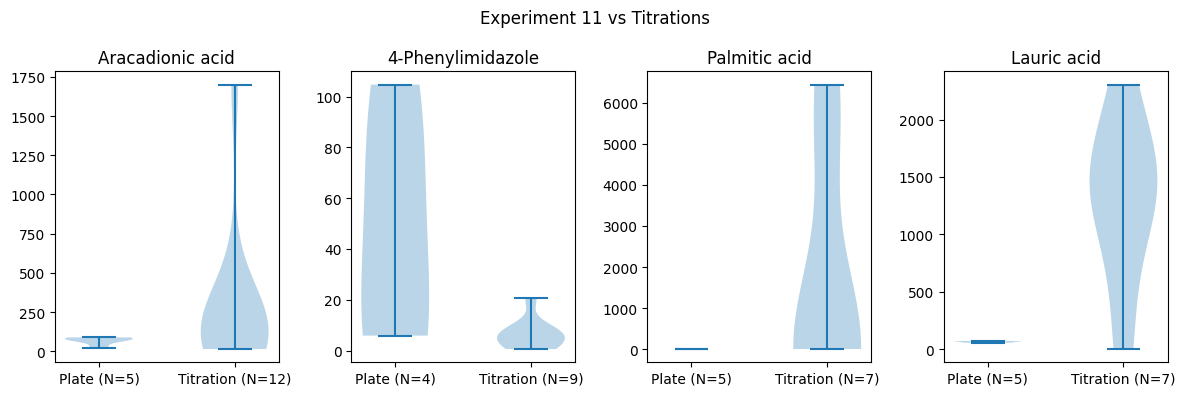

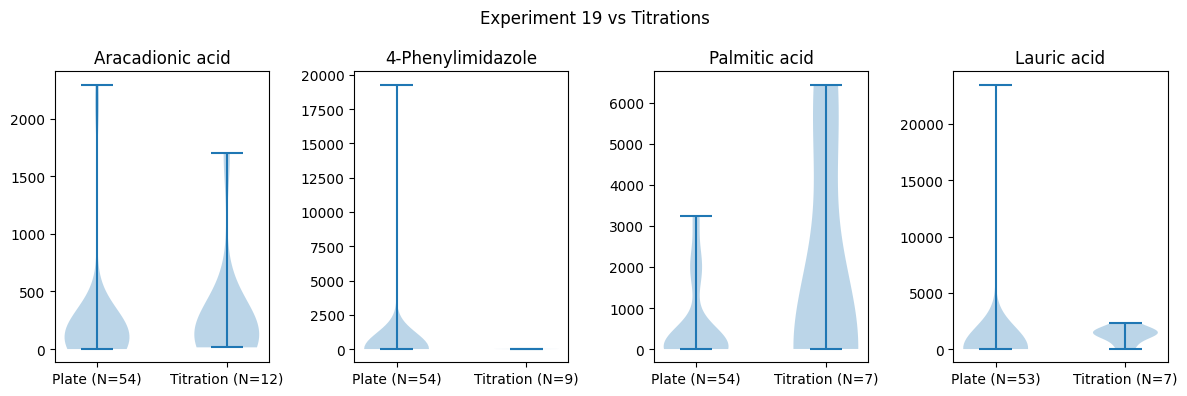

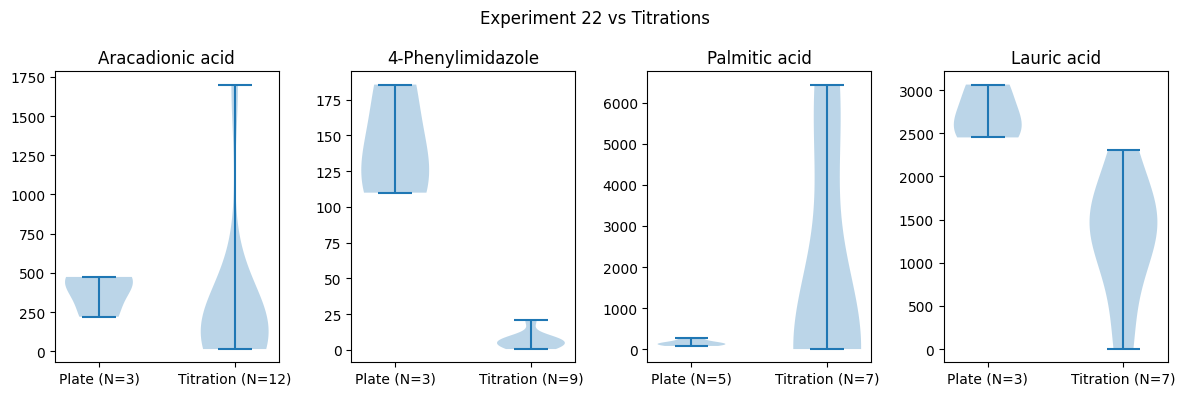

In [97]:
import itertools
import numpy as np



for experiment_number in [11, 19, 22]:
    df_experiment = df.query(f'experiment_number == {experiment_number}')
    common_ligands =  set(df_experiment['ligand']).intersection(set(titration_metrics['ligand']))
    fig, axs = plt.subplots(1, len(common_ligands), figsize=(12, 4))
    for ligand, ax in zip(common_ligands, axs.flatten()):
        df_experiment_ligand = df_experiment.query(f'ligand == "{ligand}"')
        df_experiment_ligand_ok = df_experiment_ligand.query('ok == True')
        titrations_ligand = titration_metrics.query(f'ligand == "{ligand}"')
        ax.violinplot([
            df_experiment_ligand_ok['km'],
            titrations_ligand['km']
        ])
        ax.set_title(ligand)
        ax.set_xticks([1, 2], [f'Plate (N={len(df_experiment_ligand_ok)})', 
                               f'Titration (N={len(titrations_ligand)})'])

    fig.suptitle(f'Experiment {experiment_number} vs Titrations')
    plt.tight_layout()
    plt.show()

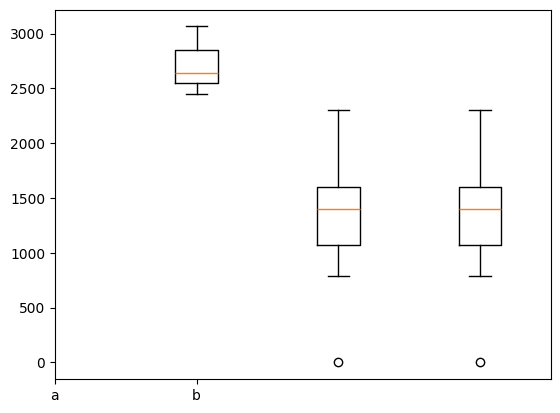

In [84]:
plt.boxplot([df_experiment_ligand_ok['km'],
            titrations_ligand['km'],
            titrations_ligand['km'],
            ])

plt.xticks([0, 1], ['a', 'b'])
plt.show()

In [54]:
df_experiment_ligand_ok['km']

315    3064.235121
327    2451.820534
331    2638.827129
Name: km, dtype: float64

In [55]:
titrations_ligand['km']

0    1.366392e+03
1    1.619429e+03
2    1.578336e+03
3    2.305610e+03
4    1.399288e+03
5    1.428215e-12
6    7.849218e+02
Name: km, dtype: float64

(array([[1., 0., 0., 1., 0., 1., 2., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 1., 0., 1., 2., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 1., 0., 1., 2., 1., 0., 1.]]),
 array([2451.82053422, 2513.06199287, 2574.30345151, 2635.54491016,
        2696.7863688 , 2758.02782745, 2819.26928609, 2880.51074474,
        2941.75220339, 3002.99366203, 3064.23512068]),
 array([1.42821519e-12, 2.30561011e+02, 4.61122021e+02, 6.91683032e+02,
        9.22244043e+02, 1.15280505e+03, 1.38336606e+03, 1.61392707e+03,
        1.84448809e+03, 2.07504910e+03, 2.30561011e+03]),
 <matplotlib.collections.QuadMesh at 0x778366682fb0>)

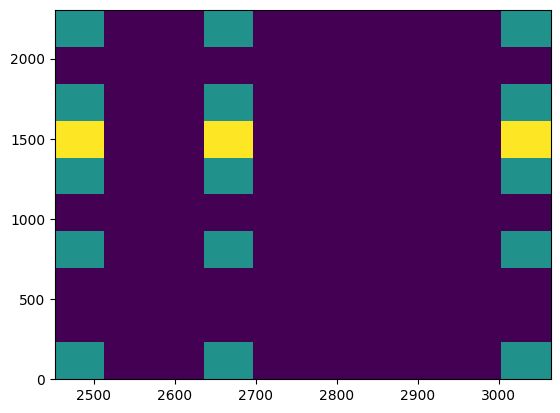

In [64]:
plt.hist2d(
    x=pairwise[:, 0],
    y=pairwise[:, 1]
)

ValueError: x and y must have the same length.

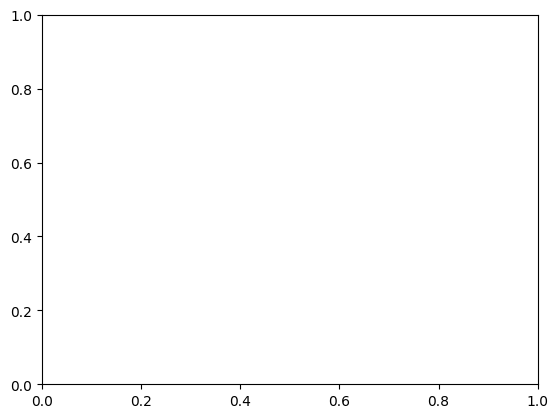

In [61]:
plt.hist2d([1,2,3],  
           [2,3])